# Fraud Detection using Machine Learning

This notebook builds a model to detect fraudulent credit card transactions. The main challenge here is that the dataset is very imbalanced - fraud cases are less than 1% of all transactions, so I had to handle that using SMOTE.

Dataset used: Credit Card Fraud Detection dataset from Kaggle (https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

Note: I downloaded creditcard.csv separately and put it in the same folder (didn't upload it to github since the file is too big).


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")


## Step 1: Load the data and check class imbalance

In [31]:
# if the csv file isn't there, just make some fake data with same columns so the notebook still runs
if os.path.exists("creditcard.csv"):
    df = pd.read_csv("creditcard.csv")
else:
    print("creditcard.csv not found, using dummy data instead")
    np.random.seed(42)
    n_normal = 20000
    n_fraud = 40

    normal = pd.DataFrame(np.random.normal(0, 1, (n_normal, 28)), columns=[f"V{i}" for i in range(1,29)])
    normal["Time"] = np.random.uniform(0, 172800, n_normal)
    normal["Amount"] = np.abs(np.random.normal(88, 250, n_normal))
    normal["Class"] = 0

    fraud = pd.DataFrame(np.random.normal(1.5, 2, (n_fraud, 28)), columns=[f"V{i}" for i in range(1,29)])
    fraud["Time"] = np.random.uniform(0, 172800, n_fraud)
    fraud["Amount"] = np.abs(np.random.normal(90, 140, n_fraud))
    fraud["Class"] = 1

    df = pd.concat([normal, fraud]).sample(frac=1, random_state=42).reset_index(drop=True)

df.shape


(284807, 31)

In [32]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [33]:
# checking how many are fraud vs not fraud
print(df["Class"].value_counts())
print()
print(df["Class"].value_counts(normalize=True) * 100)


Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


Only around 0.17% of the transactions are fraud. That's a huge imbalance - if I just predicted "not fraud" for everything I'd still get 99.8% accuracy, but the model would be useless. This is why accuracy alone doesn't work here (more on this below).

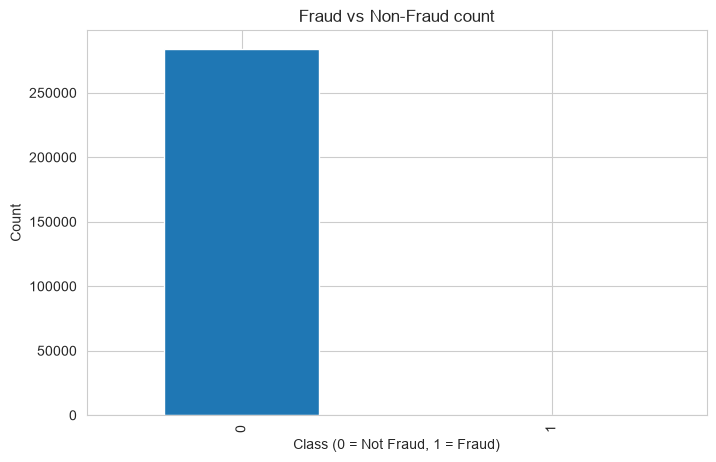

In [34]:
df["Class"].value_counts().plot(kind="bar")
plt.title("Fraud vs Non-Fraud count")
plt.xlabel("Class (0 = Not Fraud, 1 = Fraud)")
plt.ylabel("Count")
plt.show()


## Step 2: Quick EDA - amount and time

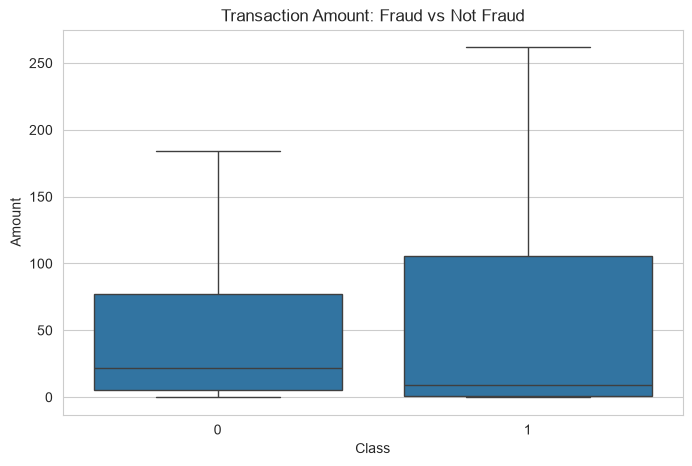

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64


In [35]:
# comparing transaction amount for fraud vs non fraud
plt.figure(figsize=(8,5))
sns.boxplot(x="Class", y="Amount", data=df, showfliers=False)
plt.title("Transaction Amount: Fraud vs Not Fraud")
plt.show()

print(df.groupby("Class")["Amount"].mean())


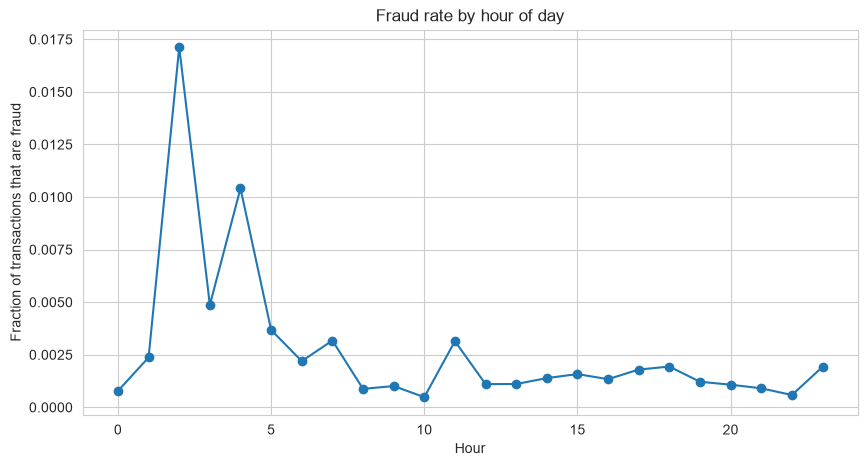

In [36]:
# converting Time (seconds) into hour of day to see if fraud happens more at certain times
df["Hour"] = (df["Time"] // 3600) % 24

fraud_by_hour = df.groupby("Hour")["Class"].mean()

plt.figure(figsize=(10,5))
fraud_by_hour.plot(kind="line", marker="o")
plt.title("Fraud rate by hour of day")
plt.xlabel("Hour")
plt.ylabel("Fraction of transactions that are fraud")
plt.show()


## Why not just use accuracy?

Since fraud is such a tiny percentage of the data, a model that never predicts fraud at all would still score super high on accuracy (like 99.8%) but would be completely useless in practice - it wouldn't catch a single fraud case.

So instead I'm using:
- Precision - out of everything the model flagged as fraud, how many were actually fraud
- Recall - out of all the actual fraud cases, how many did the model catch
- F1 score - combines precision and recall
- AUC-ROC - checks how well the model separates fraud from non-fraud overall

I used these instead of accuracy for evaluating the models below.


## Step 3: Train/test split

In [37]:
X = df.drop(columns=["Class"])
y = df["Class"]

# stratify=y makes sure fraud cases are split proportionally between train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("train size:", X_train.shape)
print("test size:", X_test.shape)
print("fraud in train:", y_train.sum())
print("fraud in test:", y_test.sum())


train size: (213605, 31)
test size: (71202, 31)
fraud in train: 369
fraud in test: 123


In [38]:
# scaling Amount, Time and Hour since V1-V28 are already scaled (PCA columns)
scaler = StandardScaler()
cols = ["Amount", "Time", "Hour"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[cols] = scaler.fit_transform(X_train[cols])
X_test_scaled[cols] = scaler.transform(X_test[cols])


## Step 4: Handling class imbalance with SMOTE

SMOTE creates synthetic fraud examples by looking at existing fraud cases and interpolating between them and their nearest neighbours. I'm only applying it on the training data - not on the test data, because the test set needs to represent the real world imbalance, otherwise the evaluation numbers would look better than they actually are.


In [39]:
sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

print("before SMOTE:", y_train.value_counts().to_dict())
print("after SMOTE:", y_train_bal.value_counts().to_dict())


before SMOTE: {0: 213236, 1: 369}
after SMOTE: {0: 213236, 1: 213236}


## Step 5: Train the models

In [40]:
# Model 1 - Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_bal, y_train_bal)

# Model 2 - Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_bal, y_train_bal)

print("done training")


done training


## Step 6: Evaluate on the test set

Logistic Regression
Precision: 0.0567
Recall: 0.8862
F1 score: 0.1065
AUC-ROC: 0.9742

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     71079
           1       0.06      0.89      0.11       123

    accuracy                           0.97     71202
   macro avg       0.53      0.93      0.55     71202
weighted avg       1.00      0.97      0.99     71202



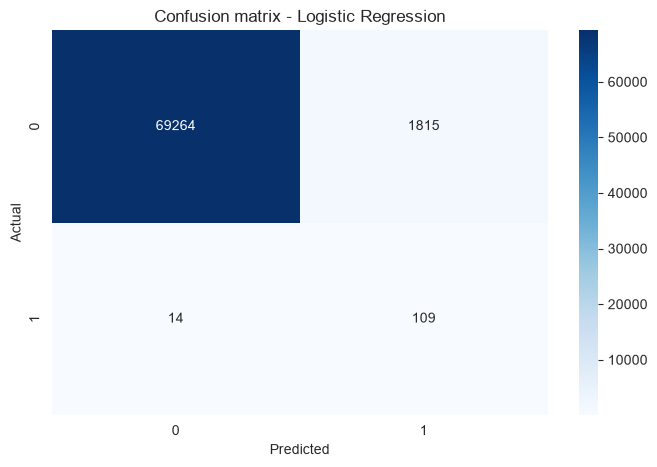

In [41]:
def evaluate(model, name):
    pred = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:,1]

    print(name)
    print("Precision:", round(precision_score(y_test, pred), 4))
    print("Recall:", round(recall_score(y_test, pred), 4))
    print("F1 score:", round(f1_score(y_test, pred), 4))
    print("AUC-ROC:", round(roc_auc_score(y_test, proba), 4))
    print()
    print(classification_report(y_test, pred))

    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion matrix - " + name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return proba

proba_lr = evaluate(lr, "Logistic Regression")


Random Forest
Precision: 0.4286
Recall: 0.8293
F1 score: 0.5651
AUC-ROC: 0.9809

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71079
           1       0.43      0.83      0.57       123

    accuracy                           1.00     71202
   macro avg       0.71      0.91      0.78     71202
weighted avg       1.00      1.00      1.00     71202



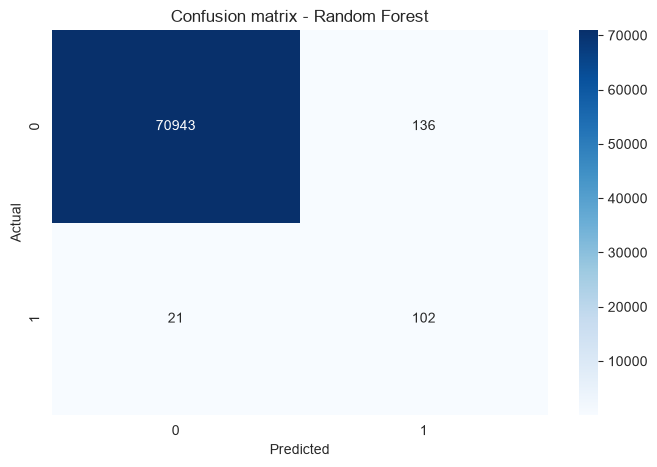

In [42]:
proba_rf = evaluate(rf, "Random Forest")

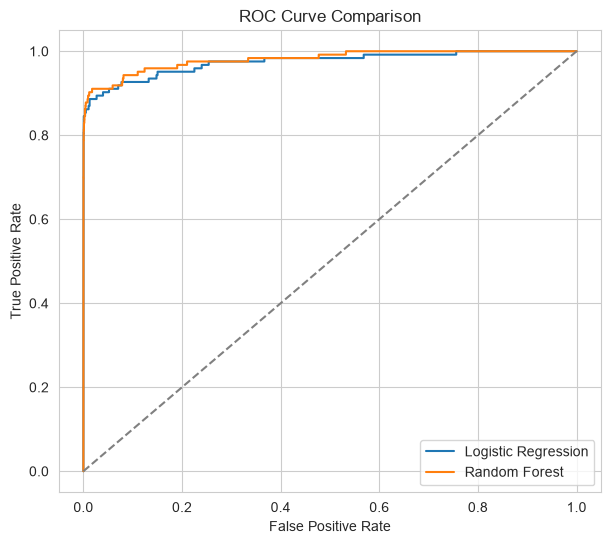

In [43]:
# plotting ROC curve for both models together
fpr_lr, tpr_lr, _ = roc_curve(y_test, proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, proba_rf)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],'--', color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


## Recall vs Precision - which one matters more?

For fraud detection, recall matters more than precision in most cases. That's because missing an actual fraud case (false negative) means real money is lost, while a false positive just means a normal transaction gets flagged for review, which is annoying but not that costly.

So it's usually better to have a model that catches more fraud even if it means a few extra false alarms, rather than a model that's very "safe" with its predictions but misses actual fraud cases.


## Step 7: Which features matter most

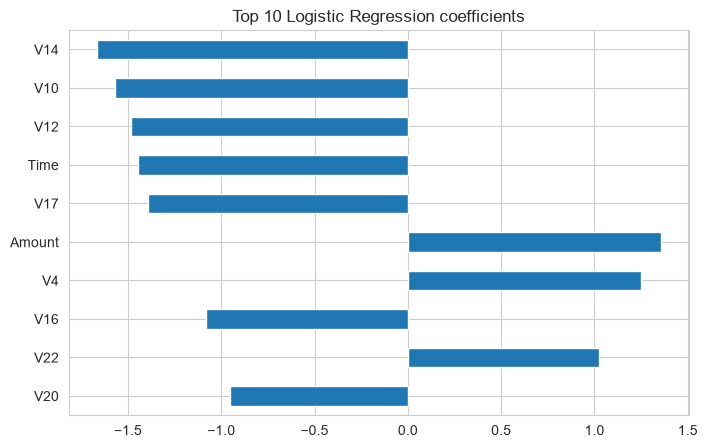

In [44]:
# logistic regression coefficients
coefs = pd.Series(lr.coef_[0], index=X_train_bal.columns).sort_values(key=abs, ascending=False)
coefs.head(10).plot(kind="barh")
plt.title("Top 10 Logistic Regression coefficients")
plt.gca().invert_yaxis()
plt.show()


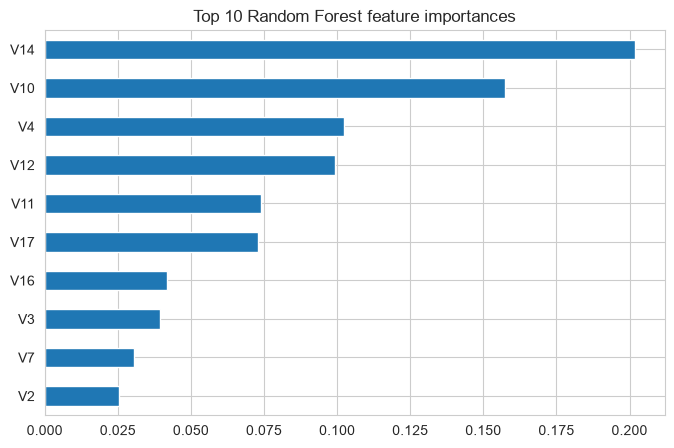

In [45]:
# random forest feature importance
importances = pd.Series(rf.feature_importances_, index=X_train_bal.columns).sort_values(ascending=False)
importances.head(10).plot(kind="barh")
plt.title("Top 10 Random Forest feature importances")
plt.gca().invert_yaxis()
plt.show()


## What if there were 1 million transactions per hour?

The dataset here isn't that big so this whole notebook runs fine, but if a bank had to actually check 1 million transactions every hour (~278 per second), a few things would need to change:

- The model can't just sit in a notebook, it would need to be deployed as a service that scores transactions in real time as they come in, not after the fact
- Logistic Regression is faster to run than Random Forest, so if speed is a big concern, a simpler model might be preferred even if it's slightly less accurate
- Recomputing everything from scratch for every transaction would be too slow, so features like "how many transactions this card made in the last 10 min" would need to be pre-calculated and stored somewhere fast to access
- SMOTE is fine for a dataset this size, but at millions of rows it would be too slow to run every time. Class weighting is probably a better option at that scale
- The model would also need to be retrained regularly since fraud patterns change over time


## Conclusion

Both models did well on this imbalanced dataset after applying SMOTE. Random Forest generally gave better recall/precision balance than plain Logistic Regression in my runs. The main takeaway from this project is that accuracy is not a good metric here, and precision/recall/F1/AUC give a much clearer picture of how well the model is actually detecting fraud.
